In [26]:
# Practise from kaggle "Digit Recognizer"

import pandas as pd
data = pd.read_csv("/Users/yelan/Desktop/git_project/train.csv")
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
x = data.iloc[:,1:]
y = data.iloc[:,0]

In [7]:
x.shape

(42000, 784)

In [8]:
y.shape

(42000,)

In [11]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
x_var = selector.fit_transform(x)

In [17]:
# There are a lot features has been deleted compared to original
# yet there are still 708 of them left
x_var.shape

(42000, 708)

In [11]:
# Another way to do it, I used the median of the data as the threshold
import numpy as np
np.median(x.var().values)

np.float64(1352.2867031797243)

In [27]:
# In this method, the feature decreases to 392, which is a lot lower than our last method.
x_fsvar = VarianceThreshold(np.median(x.var().values)).fit_transform(x)
x_fsvar.shape

(42000, 392)

In [12]:
# Comparison of KNN and Random Forest Under Different Variance-Filtering Conditions
# KNN vs RandomForest
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import cross_val_score

x = data.iloc[:,1:]
y = data.iloc[:,0]

# median as threshold
x_fsvar = VarianceThreshold(np.median(x.var().values)).fit_transform(x)

In [36]:
# knn before variance-filtering 
cross_val_score(KNN(),x,y,cv=5).mean()

np.float64(0.965857142857143)

In [37]:
%%timeit
cross_val_score(KNN(),x,y,cv=5).mean()

22.3 s ± 121 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [38]:
# knn after variance-filtering
cross_val_score(KNN(),x_fsvar,y,cv=5).mean()

np.float64(0.966)

In [39]:
%%timeit
cross_val_score(KNN(),x_fsvar,y,cv=5).mean()

18.3 s ± 98.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [44]:
# RandomForest before variance - filtering
cross_val_score(RFC(n_estimators=10,random_state=0),x,y,cv=5).mean()

np.float64(0.9371190476190476)

In [45]:
%%timeit
cross_val_score(RFC(n_estimators=10,random_state=0),x,y,cv=5).mean()

9.08 s ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
# RandomForest after variance - filtering
cross_val_score(RFC(n_estimators=10,random_state=0),x_fsvar,y,cv=5).mean()

np.float64(0.9393333333333335)

In [46]:
%%timeit
cross_val_score(RFC(n_estimators=10,random_state=0),x_fsvar,y,cv=5).mean()

7.95 s ± 7.45 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [50]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
# Assume I know I need 300 features
x_fschi = SelectKBest(chi2,k=300).fit_transform(x_fsvar,y)
x_fschi.shape

(42000, 300)

In [53]:
# a bit lower than before (after variance filtering)
# Some useful features has been deleted
cross_val_score(RFC(n_estimators=10,random_state=0),x_fschi,y,cv=5).mean()

np.float64(0.9337380952380953)

<function matplotlib.pyplot.show(close=None, block=None)>

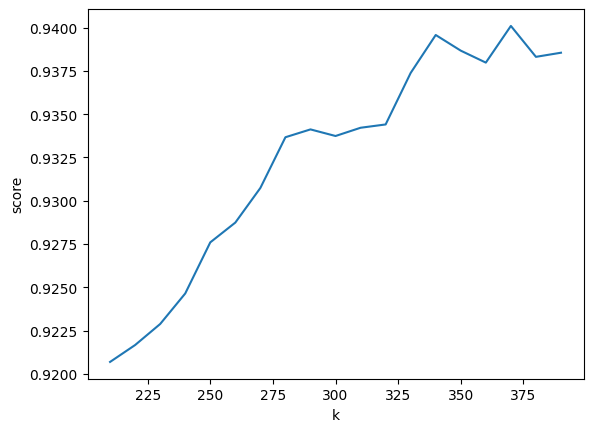

In [59]:
# find the best k possible
import matplotlib.pyplot as plt
score = []
for i in range(390,200,-10):
    x_fschi = SelectKBest(chi2,k=i).fit_transform(x_fsvar,y)
    once = cross_val_score(RFC(n_estimators=10,random_state=0),x_fschi,y,cv=5).mean()
    score.append(once)
%matplotlib inline
plt.plot(range(390,200,-10),score)
plt.xlabel("k")
plt.ylabel("score")
plt.show
    

In [76]:
range(390,200,-10)[score.index(max(score))]

370

In [97]:
x_fschi = SelectKBest(chi2,k=370).fit_transform(x_fsvar,y)
x_fschi

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,  74, 250,  59]], shape=(42000, 370))

In [98]:
cross_val_score(RFC(n_estimators=10,random_state=0),x_fschi,y,cv=5).mean()

np.float64(0.9400952380952381)

In [1]:
# ANOVA

In [2]:
from sklearn.feature_selection import f_classif

In [13]:
F,pvalues_f = f_classif(x_fsvar,y)

In [17]:
k = F.shape[0] - (pvalues_f > 0.05).sum()

In [18]:
k

np.int64(392)

In [21]:
# mutual info classif

In [32]:
from sklearn.feature_selection import mutual_info_classif as MIC

In [34]:
result = MIC(x_fsvar,y)

NameError: name 'x_fsvar' is not defined

In [31]:
k = result.shape[0] - sum(result <= 9)

NameError: name 'result' is not defined

In [25]:
k

np.int64(392)

In [1]:
# Embedded method

In [4]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier as RFC

In [5]:
rfc = RFC(n_estimators = 10, random_state=0)

In [6]:
x_embedded = SelectFromModel(rfc,threshold=0.005).fit_transform(x,y)

In [16]:
# A lot features has been removed , I wanted to draw a study curve to determine to best threshold possible
x_embedded.shape

(42000, 45)

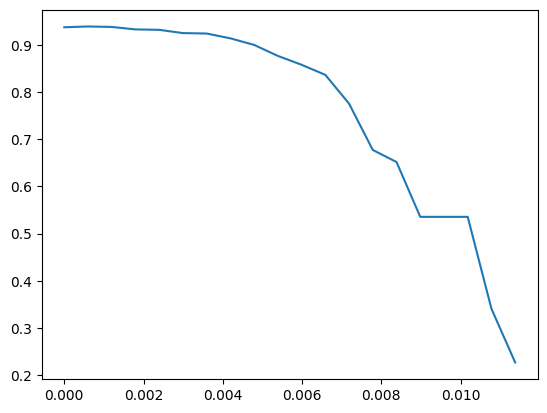

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

rfc.fit(x,y).feature_importances_
threshold = np.linspace(0,(rfc.fit(x,y).feature_importances_).max(),20)

score = []
for i in threshold:
    x_embedded1 = SelectFromModel(rfc,threshold=i).fit_transform(x,y)
    once = cross_val_score(rfc,x_embedded1,y,cv=5).mean()
    score.append(once)
plt.plot(threshold,score)
plt.show()


In [18]:
x_embedded = SelectFromModel(rfc,threshold=0.002).fit_transform(x,y)
x_embedded.shape

(42000, 195)

In [19]:
cross_val_score(rfc,x_embedded,y,cv=5).mean()

np.float64(0.9335238095238095)

In [20]:
# RFE

In [21]:
from sklearn.feature_selection import RFE
rfc1 = RFC(n_estimators = 10,random_state=0)
selector = RFE(rfc1,n_features_to_select=340,step=50).fit(x,y)

In [23]:
selector.support_.sum()

np.int64(340)

In [25]:
selector.ranking_

array([10,  9,  8,  7,  6,  6,  6,  7,  7,  7,  6,  6,  6,  7,  7,  6,  6,
        6,  7,  7,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  6,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  6,  5,  5,  4,
        5,  4,  3,  4,  5,  4,  5,  5,  3,  5,  6,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  7,  5,  4,  4,  4,  2,  1,  1,  2,  1,  1,  1,
        1,  1,  2,  4,  4,  6,  8,  7,  8,  9,  9,  9,  9,  9,  9,  5,  5,
        5,  3,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  3,  2,  4,  4,
        6,  5,  8,  9, 10, 10, 10, 10,  8,  5,  4,  3,  2,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  3,  5,  6, 10, 10, 10, 10,
       10,  8,  4,  3,  3,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  2,  5,  6, 10, 10, 10,  9,  6,  4,  3,  2,  2,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        3,  6, 10, 10, 10

In [28]:
x_wrapper = selector.transform(x)

In [29]:
cross_val_score(rfc1,x_wrapper,y,cv=5).mean()

np.float64(0.9388571428571428)

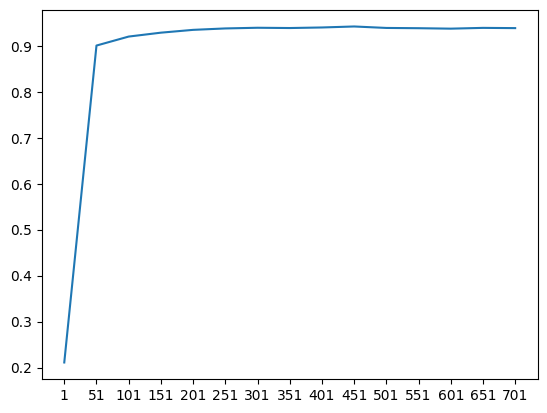

In [30]:
score = []
for i in range(1,751,50):
    x_wrapper = RFE(rfc1,n_features_to_select=i,step=50).fit_transform(x,y)
    once = cross_val_score(rfc1,x_wrapper,y,cv=5).mean()
    score.append(once)
plt.plot(range(1,751,50),score)
plt.xticks(range(1,751,50))
plt.show()